# IAM Preprocessing — Step by Step

Questo notebook esegue la pipeline di preprocessing IAM **uno step alla volta**,
salvando e visualizzando il risultato intermedio ad ogni passaggio, cosi da
capire esattamente cosa succede tra l'immagine originale e l'output finale 448x448.

Pipeline:
1. Caricamento immagine originale
2. Binarizzazione di Otsu (grayscale + binary)
3. Rilevamento linee guida (morphological opening)
4. Selezione della fascia di scrittura (y_start, y_end)
5. Estrazione della regione (crop verticale)
6. Rimozione colonna nera a sinistra
7. Tight crop (proiezioni assiali)
8. Resize finale a 448x448

Ad ogni step salviamo il PNG intermedio in `./steps_output/` e lo visualizziamo inline.


## 0. Setup e configurazione

In [5]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

# ==================== CONFIGURAZIONE ====================
IMAGE_PATH = "../datasets/IAM/data/000/a01-000u.png" 

OUTPUT_DIR = "steps_output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_SIZE = 448

def show_and_save(img, title, filename, cmap="gray"):
    """Salva l'immagine intermedia su disco e la mostra inline"""
    out_path = os.path.join(OUTPUT_DIR, filename)
    cv2.imwrite(out_path, img)
    plt.figure(figsize=(10, 12))
    plt.imshow(img, cmap=cmap)
    plt.title(f"{title}\nshape: {img.shape}  |  salvato in: {out_path}")
    plt.axis("off")
    plt.show()
    print(f"Salvato: {out_path}  |  shape: {img.shape}")


## 1. Caricamento immagine originale

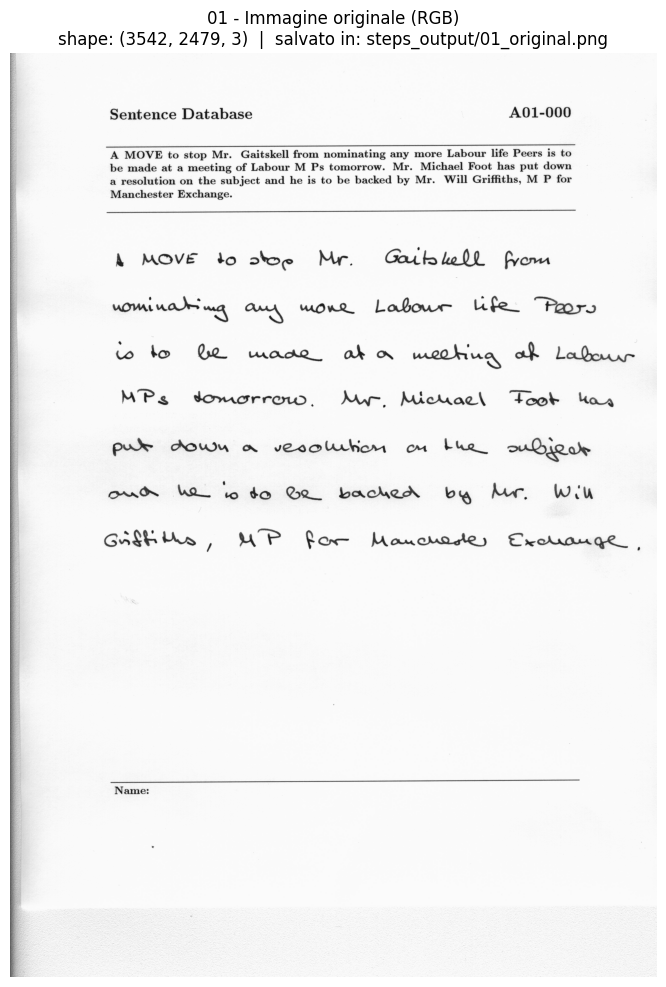

Salvato: steps_output/01_original.png  |  shape: (3542, 2479, 3)


In [6]:
image = cv2.imread(IMAGE_PATH)
assert image is not None, f"Immagine non trovata: {IMAGE_PATH}"

show_and_save(cv2.cvtColor(image, cv2.COLOR_BGR2RGB), "01 - Immagine originale (RGB)", "01_original.png", cmap=None)


## 2. Binarizzazione di Otsu

Convertiamo in grayscale e calcoliamo la maschera binaria con Otsu.
Da qui in poi teniamo **due immagini in parallelo**, sempre allineate spazialmente:
- `gray`: quella che verrà effettivamente croppata/salvata alla fine
- `binary`: usata solo per calcolare coordinate/soglie nei prossimi step


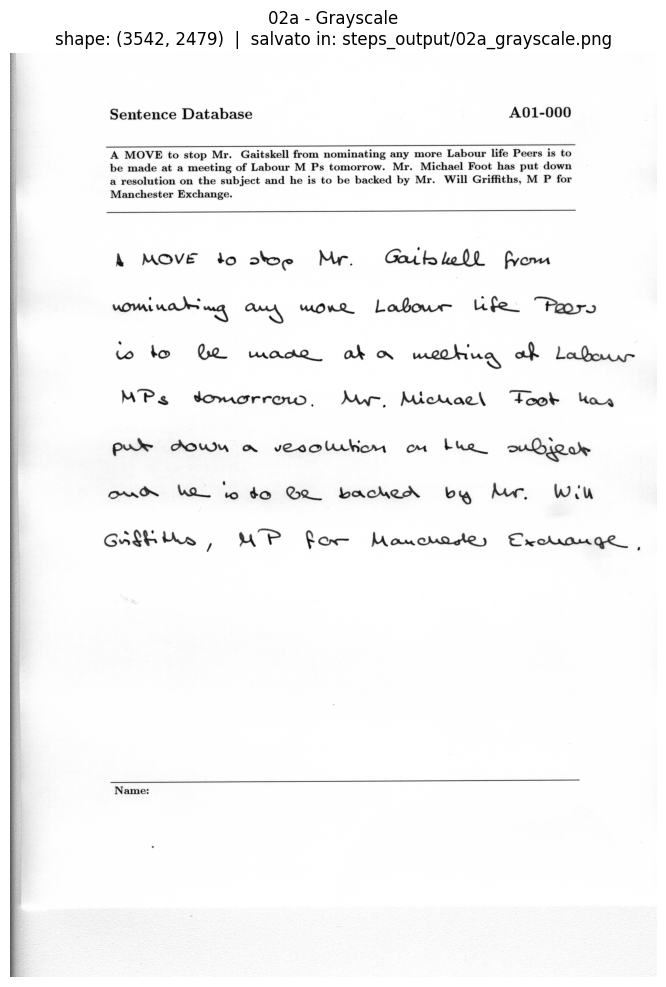

Salvato: steps_output/02a_grayscale.png  |  shape: (3542, 2479)


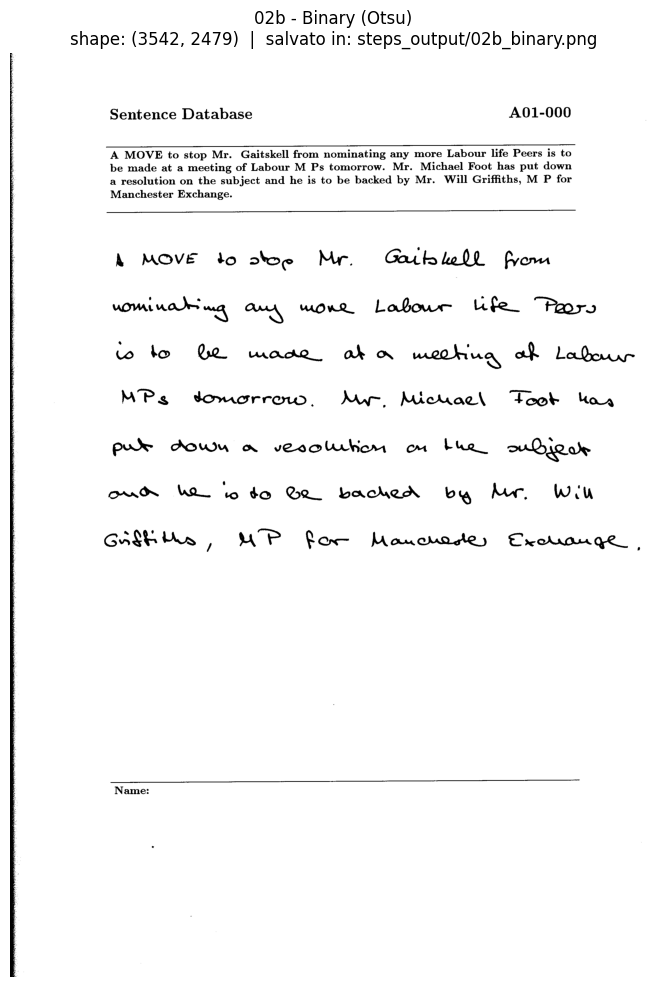

Salvato: steps_output/02b_binary.png  |  shape: (3542, 2479)


In [7]:
def apply_threshold(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return gray, binary

gray, binary = apply_threshold(image)

show_and_save(gray, "02a - Grayscale", "02a_grayscale.png")
show_and_save(binary, "02b - Binary (Otsu)", "02b_binary.png")


## 3. Rilevamento linee guida (morphological opening)

Invertiamo la binaria e applichiamo un'apertura morfologica (erode + dilate) con un
kernel orizzontale largo, cosi da far sopravvivere solo i segmenti lunghi e sottili
(le righe guida stampate), eliminando il testo.


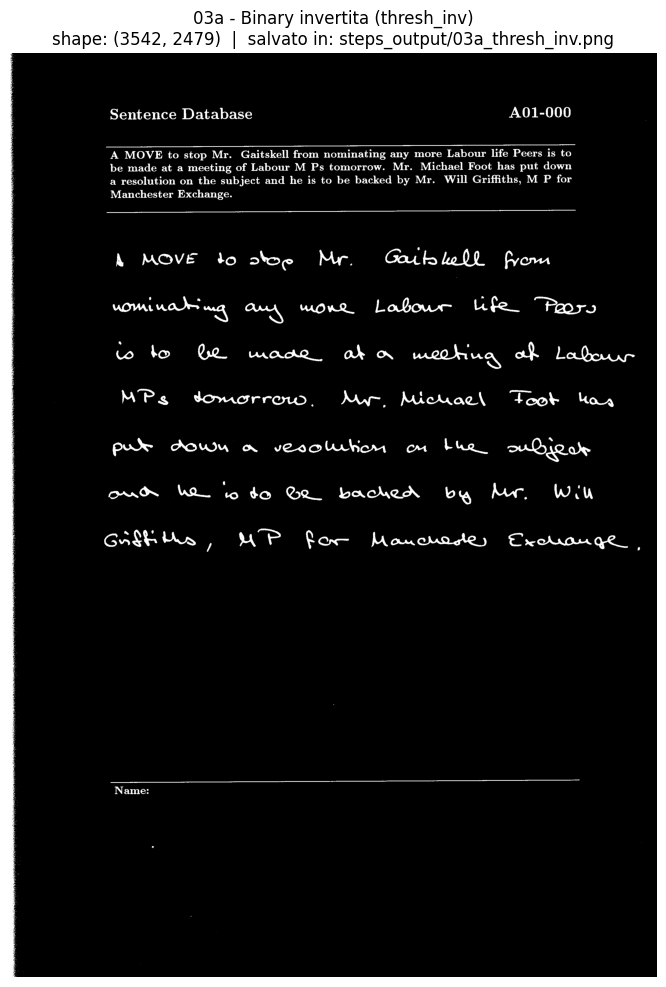

Salvato: steps_output/03a_thresh_inv.png  |  shape: (3542, 2479)


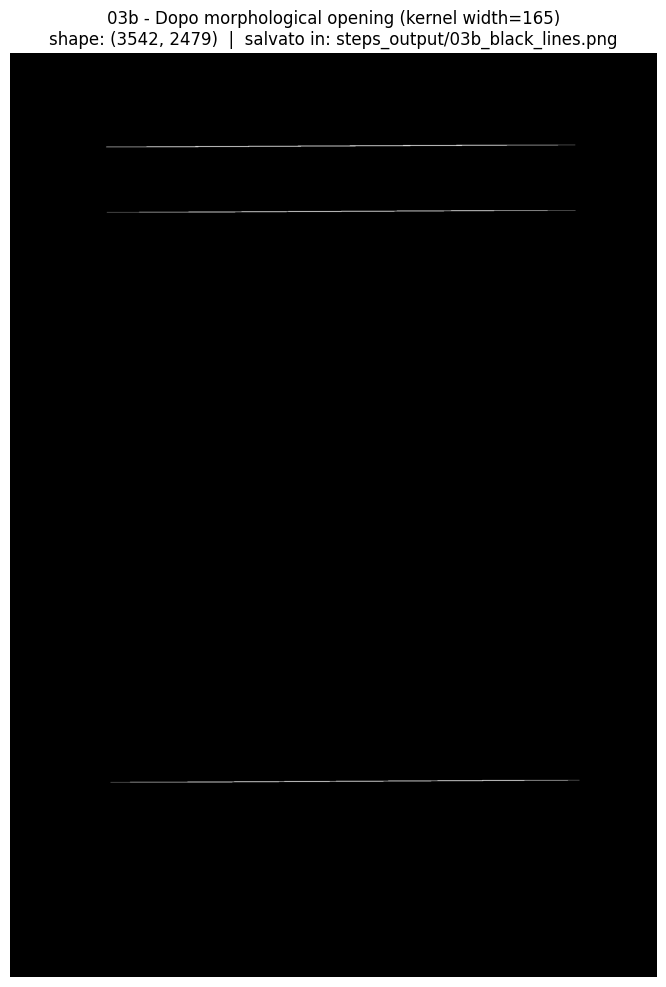

Salvato: steps_output/03b_black_lines.png  |  shape: (3542, 2479)


In [8]:
h, w = binary.shape
thresh_inv = 255 - binary

kernel_width = max(30, w // 15)
kernel = np.ones((1, kernel_width), np.uint8)
black_lines = cv2.morphologyEx(thresh_inv, cv2.MORPH_OPEN, kernel, iterations=2)

show_and_save(thresh_inv, "03a - Binary invertita (thresh_inv)", "03a_thresh_inv.png")
show_and_save(black_lines, f"03b - Dopo morphological opening (kernel width={kernel_width})", "03b_black_lines.png")


### 3.1 Filtraggio contorni -> linee guida valide

Trovate 3 linee guida valide
  linea 0: y_top=352, y_bottom=361, width=1798
  linea 1: y_top=603, y_bottom=611, width=1796
  linea 2: y_top=2787, y_bottom=2796, width=1797


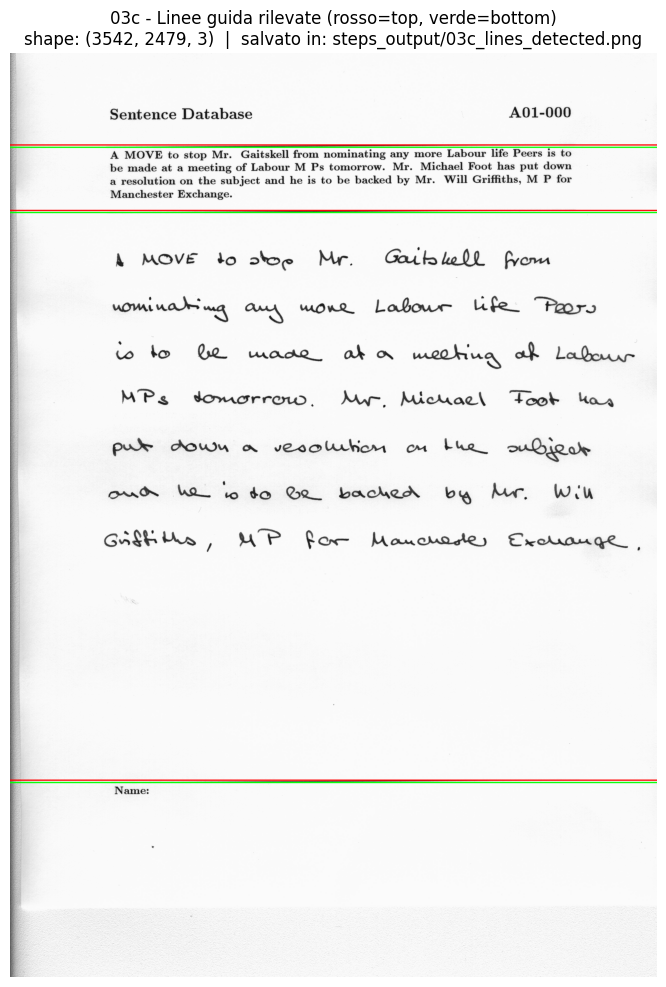

Salvato: steps_output/03c_lines_detected.png  |  shape: (3542, 2479, 3)


In [9]:
contours, _ = cv2.findContours(black_lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

valid_lines = []
for c in contours:
    x, y, cw, ch = cv2.boundingRect(c)
    area = cv2.contourArea(c)
    if cw > w * 0.3 and ch < 20 and area > 100:
        valid_lines.append({
            "y_top": y, "y_bottom": y + ch, "y_center": y + ch // 2,
            "height": ch, "width": cw
        })

valid_lines = sorted(valid_lines, key=lambda l: l["y_center"])
print(f"Trovate {len(valid_lines)} linee guida valide")
for i, l in enumerate(valid_lines):
    print(f"  linea {i}: y_top={l['y_top']}, y_bottom={l['y_bottom']}, width={l['width']}")

# Visualizza le linee trovate sovraimposte all'immagine grayscale
vis = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)
for l in valid_lines:
    cv2.line(vis, (0, l["y_top"]), (w, l["y_top"]), (0, 0, 255), 3)
    cv2.line(vis, (0, l["y_bottom"]), (w, l["y_bottom"]), (0, 255, 0), 3)

show_and_save(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB), "03c - Linee guida rilevate (rosso=top, verde=bottom)", "03c_lines_detected.png", cmap=None)


## 4. Selezione della fascia di scrittura

In base al numero di linee valide trovate, selezioniamo `y_start` e `y_end`.
Include il fallback "soft" (row-density smoothing) e il fallback fisso.


Metodo usato: >=3 linee (tra 2a e 3a)
y_start=619, y_end=2779  (altezza regione: 2160px su h totale=3542px)


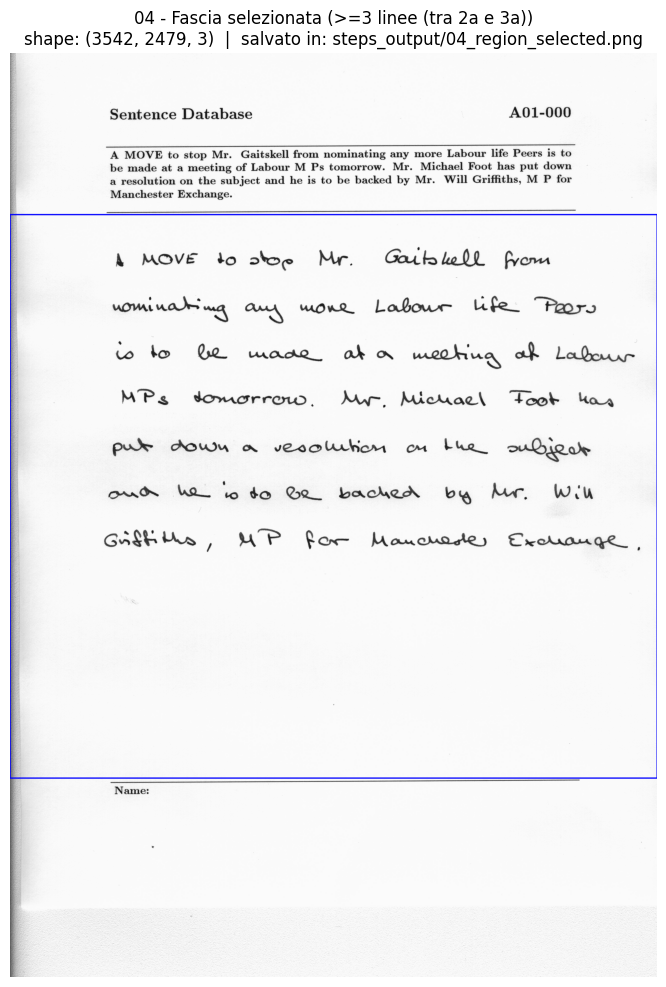

Salvato: steps_output/04_region_selected.png  |  shape: (3542, 2479, 3)


In [10]:
def select_region(valid_lines, thresh_inv, h):
    if len(valid_lines) >= 3:
        y_start = valid_lines[1]["y_bottom"] + 8
        y_end = valid_lines[2]["y_top"] - 8
        method = ">=3 linee (tra 2a e 3a)"
    elif len(valid_lines) == 2:
        y_start = valid_lines[0]["y_bottom"] + 8
        y_end = valid_lines[1]["y_top"] - 8
        method = "2 linee"
    else:
        row_density = np.sum(thresh_inv > 0, axis=1)
        smoothed = uniform_filter1d(row_density, size=5)
        threshold_line = np.percentile(smoothed, 95)
        potential_lines = np.where(smoothed > threshold_line)[0]

        if len(potential_lines) > 0:
            lines = []
            current_start = potential_lines[0]
            for i in range(1, len(potential_lines)):
                if potential_lines[i] - potential_lines[i - 1] > 5:
                    lines.append((current_start, potential_lines[i - 1]))
                    current_start = potential_lines[i]
            lines.append((current_start, potential_lines[-1]))

            if len(lines) >= 3:
                y_start = lines[1][1] + 8
                y_end = lines[2][0] - 8
                method = "fallback soft (>=3 segmenti)"
            elif len(lines) == 2:
                y_start = lines[0][1] + 8
                y_end = lines[1][0] - 8
                method = "fallback soft (2 segmenti)"
            else:
                y_start = int(h * 0.22)
                y_end = int(h * 0.85)
                method = "fallback fisso (soft insufficiente)"
        else:
            y_start = int(h * 0.22)
            y_end = int(h * 0.85)
            method = "fallback fisso (nessun segmento soft)"

    # Sanity check 1: range invalido
    if y_start >= y_end:
        y_start = int(h * 0.22)
        y_end = int(h * 0.85)
        method += " -> INVALIDO, reverted a fallback fisso"

    # Clipping
    y_start = max(0, y_start)
    y_end = min(h, y_end)

    return y_start, y_end, method

y_start, y_end, method = select_region(valid_lines, thresh_inv, h)
print(f"Metodo usato: {method}")
print(f"y_start={y_start}, y_end={y_end}  (altezza regione: {y_end - y_start}px su h totale={h}px)")

# Visualizza la fascia selezionata
vis2 = cv2.cvtColor(gray.copy(), cv2.COLOR_GRAY2BGR)
cv2.rectangle(vis2, (0, y_start), (w, y_end), (255, 0, 0), 4)
show_and_save(cv2.cvtColor(vis2, cv2.COLOR_BGR2RGB), f"04 - Fascia selezionata ({method})", "04_region_selected.png", cmap=None)


## 5. Estrazione della regione

Applichiamo `y_start`/`y_end` **sia** a `gray` **che** a `binary`, tenendole allineate.
Include il sanity check sulla dimensione minima (30x50).


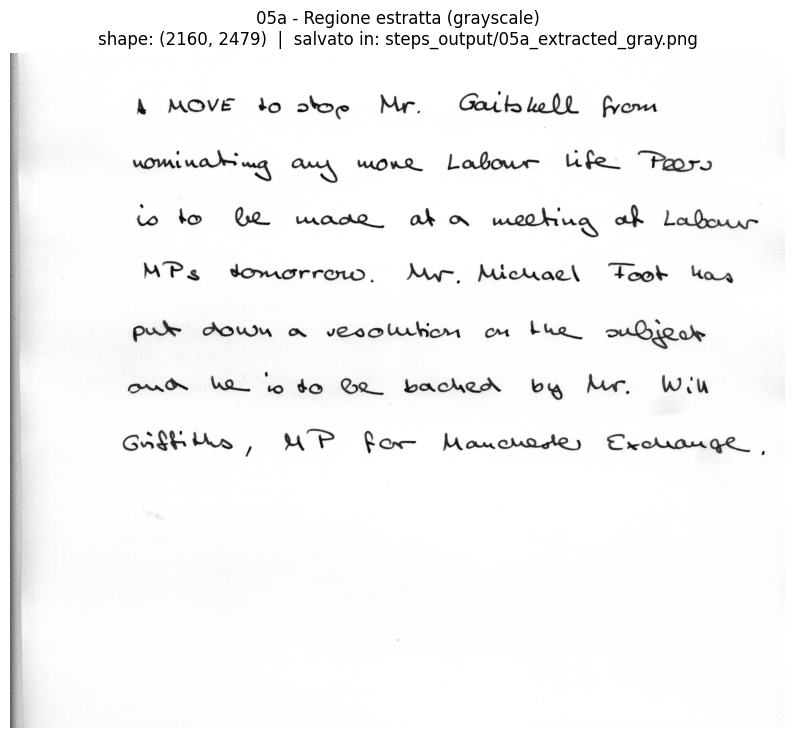

Salvato: steps_output/05a_extracted_gray.png  |  shape: (2160, 2479)


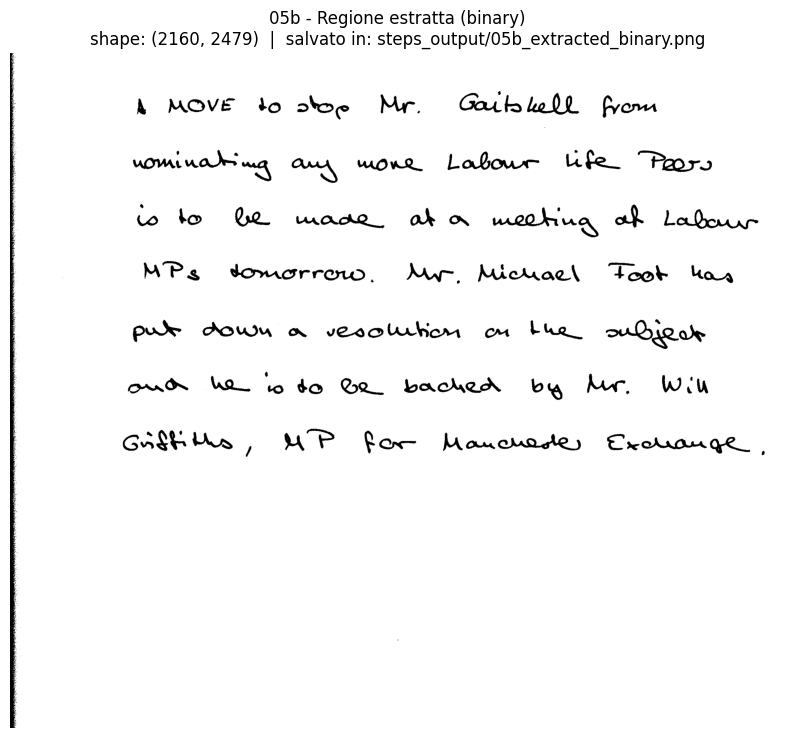

Salvato: steps_output/05b_extracted_binary.png  |  shape: (2160, 2479)


In [11]:
extracted_gray = gray[y_start:y_end, :]
extracted_binary = binary[y_start:y_end, :]

if extracted_binary.size == 0 or extracted_binary.shape[0] < 30 or extracted_binary.shape[1] < 50:
    print("Regione troppo piccola/vuota, reverto al fallback fisso")
    y_start = int(h * 0.22)
    y_end = int(h * 0.85)
    extracted_gray = gray[y_start:y_end, :]
    extracted_binary = binary[y_start:y_end, :]

show_and_save(extracted_gray, "05a - Regione estratta (grayscale)", "05a_extracted_gray.png")
show_and_save(extracted_binary, "05b - Regione estratta (binary)", "05b_extracted_binary.png")


## 6. Rimozione colonna nera a sinistra

Calcolata su `extracted_binary`, applicata a entrambe le immagini.


Prima colonna valida: 12


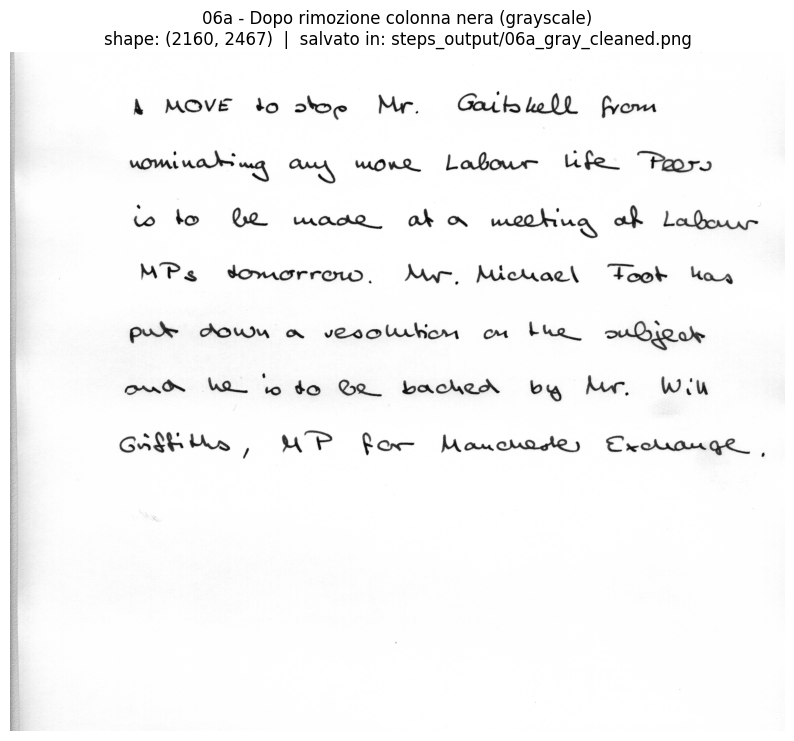

Salvato: steps_output/06a_gray_cleaned.png  |  shape: (2160, 2467)


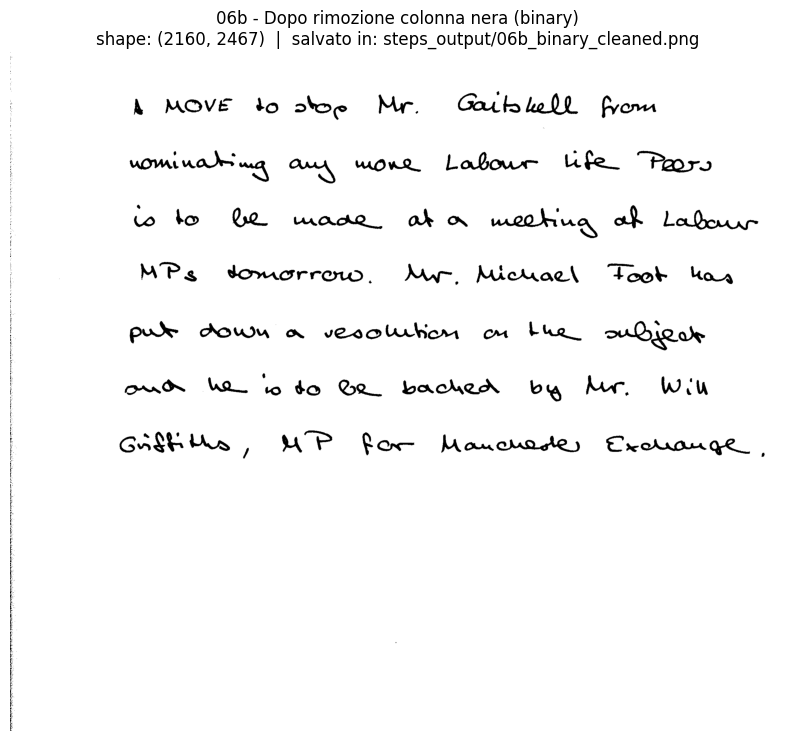

Salvato: steps_output/06b_binary_cleaned.png  |  shape: (2160, 2467)


In [12]:
def compute_left_black_columns_crop(binary_image, black_ratio_threshold=0.5):
    h, w = binary_image.shape
    black_pixels_per_col = np.sum(binary_image == 0, axis=0)
    black_ratio = black_pixels_per_col / h
    valid_cols = np.where(black_ratio <= black_ratio_threshold)[0]
    if len(valid_cols) == 0:
        return 0
    return valid_cols[0]

first_valid_col = compute_left_black_columns_crop(extracted_binary, black_ratio_threshold=0.5)
print(f"Prima colonna valida: {first_valid_col}")

gray_cleaned = extracted_gray[:, first_valid_col:]
binary_cleaned = extracted_binary[:, first_valid_col:]

show_and_save(gray_cleaned, "06a - Dopo rimozione colonna nera (grayscale)", "06a_gray_cleaned.png")
show_and_save(binary_cleaned, "06b - Dopo rimozione colonna nera (binary)", "06b_binary_cleaned.png")


## 7. Tight crop (proiezioni assiali)

Coordinate calcolate su `binary_cleaned` (rho=0.02 per IAM), applicate **solo** a
`gray_cleaned`. Da qui in poi la maschera binaria non serve più e viene scartata.


Tight crop coords: y1=134, y2=1279, x1=0, x2=2302


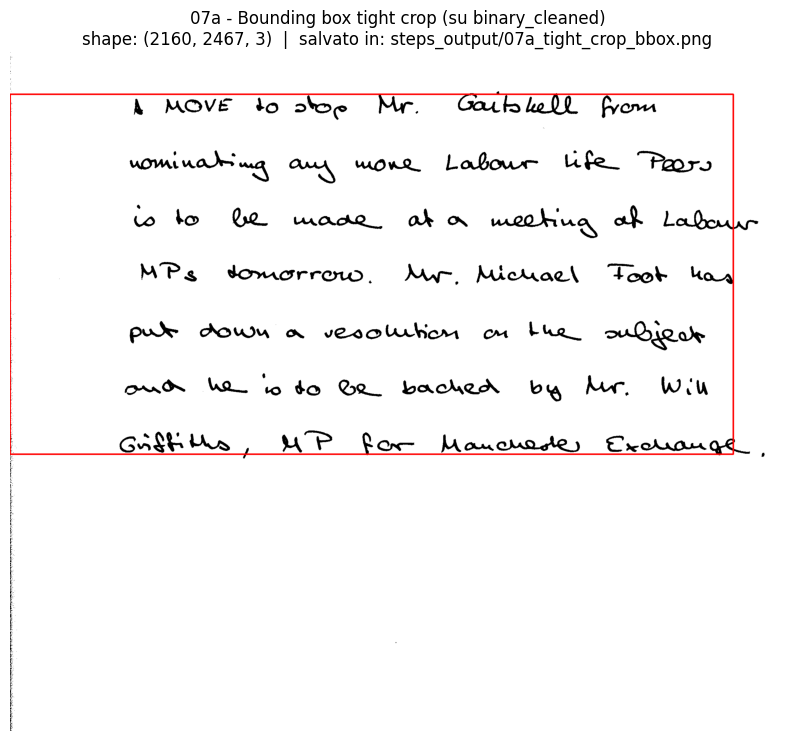

Salvato: steps_output/07a_tight_crop_bbox.png  |  shape: (2160, 2467, 3)


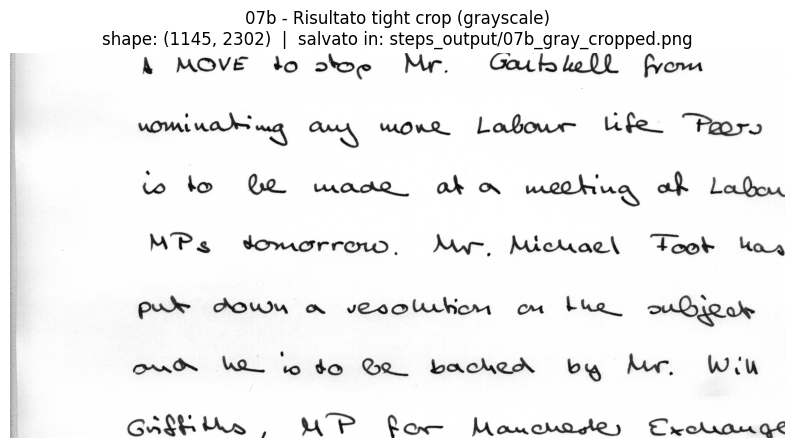

Salvato: steps_output/07b_gray_cropped.png  |  shape: (1145, 2302)


In [13]:
def compute_tight_crop_coords(binary_image, padding=5, min_pixel_ratio=0.018):
    binary_inv = 255 - binary_image
    h, w = binary_image.shape

    min_row_threshold = max(10, int(w * min_pixel_ratio))
    min_col_threshold = max(10, int(h * min_pixel_ratio))

    row_sums = np.sum(binary_inv > 0, axis=1)
    col_sums = np.sum(binary_inv > 0, axis=0)

    text_rows = np.where(row_sums > min_row_threshold)[0]
    text_cols = np.where(col_sums > min_col_threshold)[0]

    if len(text_rows) == 0 or len(text_cols) == 0:
        return None

    y1, y2 = text_rows[0], text_rows[-1]
    x1, x2 = text_cols[0], text_cols[-1]

    extra_trim = 3
    y1 = min(y1 + extra_trim, y2 - 1)
    y2 = max(y2 - extra_trim, y1 + 1)

    y1 = max(0, y1 - padding)
    y2 = min(h, y2 + padding)
    x1 = max(0, x1 - padding)
    x2 = min(w, x2 + padding)

    return (y1, y2, x1, x2)

crop_coords = compute_tight_crop_coords(binary_cleaned, padding=5, min_pixel_ratio=0.02)
assert crop_coords is not None, "Tight crop fallito: nessun testo rilevato"
y1, y2, x1, x2 = crop_coords
print(f"Tight crop coords: y1={y1}, y2={y2}, x1={x1}, x2={x2}")

# Visualizza il bounding box sulla binary_cleaned (per capire cosa e' stato individuato)
vis3 = cv2.cvtColor(binary_cleaned.copy(), cv2.COLOR_GRAY2BGR)
cv2.rectangle(vis3, (x1, y1), (x2, y2), (0, 0, 255), 3)
show_and_save(cv2.cvtColor(vis3, cv2.COLOR_BGR2RGB), "07a - Bounding box tight crop (su binary_cleaned)", "07a_tight_crop_bbox.png", cmap=None)

# Applica il crop SOLO sulla grayscale -- la binary viene scartata da qui in poi
gray_cropped = gray_cleaned[y1:y2, x1:x2]
show_and_save(gray_cropped, "07b - Risultato tight crop (grayscale)", "07b_gray_cropped.png")


## 8. Resize finale a 448x448

Centriamo l'immagine in un canvas quadrato bianco e la ridimensioniamo con
interpolazione `INTER_AREA`, preservando l'aspect ratio.


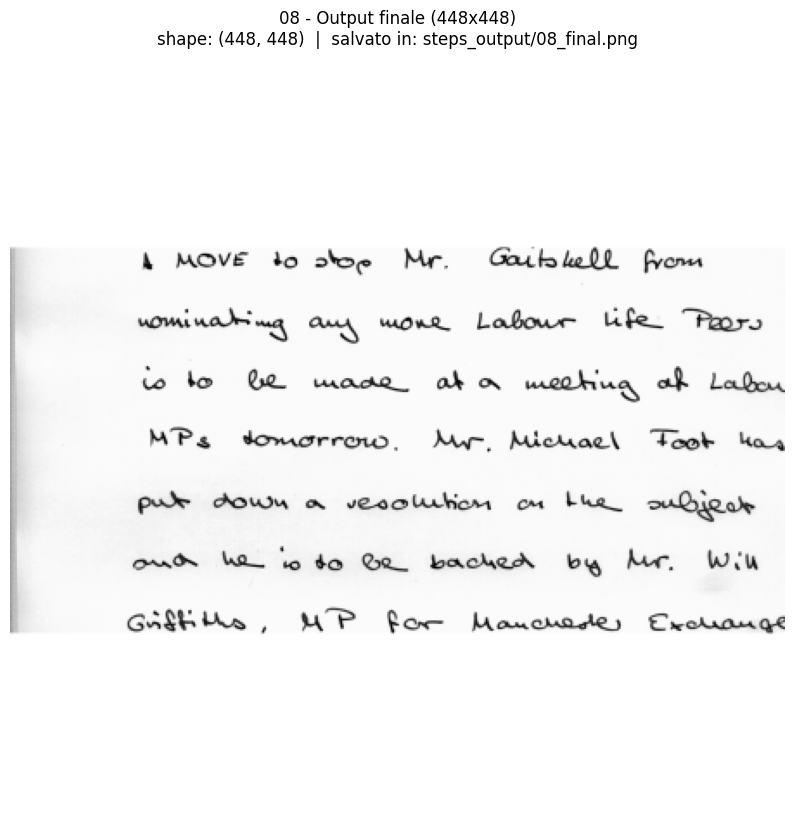

Salvato: steps_output/08_final.png  |  shape: (448, 448)

Pipeline completata. Tutti gli step intermedi sono in: steps_output/


In [14]:
def resize_to_square(image, size=TARGET_SIZE):
    h, w = image.shape
    side = max(h, w)
    square = np.full((side, side), 255, dtype=np.uint8)
    y_off, x_off = (side - h) // 2, (side - w) // 2
    square[y_off:y_off + h, x_off:x_off + w] = image
    return cv2.resize(square, (size, size), interpolation=cv2.INTER_AREA)

final = resize_to_square(gray_cropped, size=TARGET_SIZE)
show_and_save(final, f"08 - Output finale ({TARGET_SIZE}x{TARGET_SIZE})", "08_final.png")

print(f"\nPipeline completata. Tutti gli step intermedi sono in: {OUTPUT_DIR}/")


## 9. Riepilogo visivo (tutti gli step affiancati)

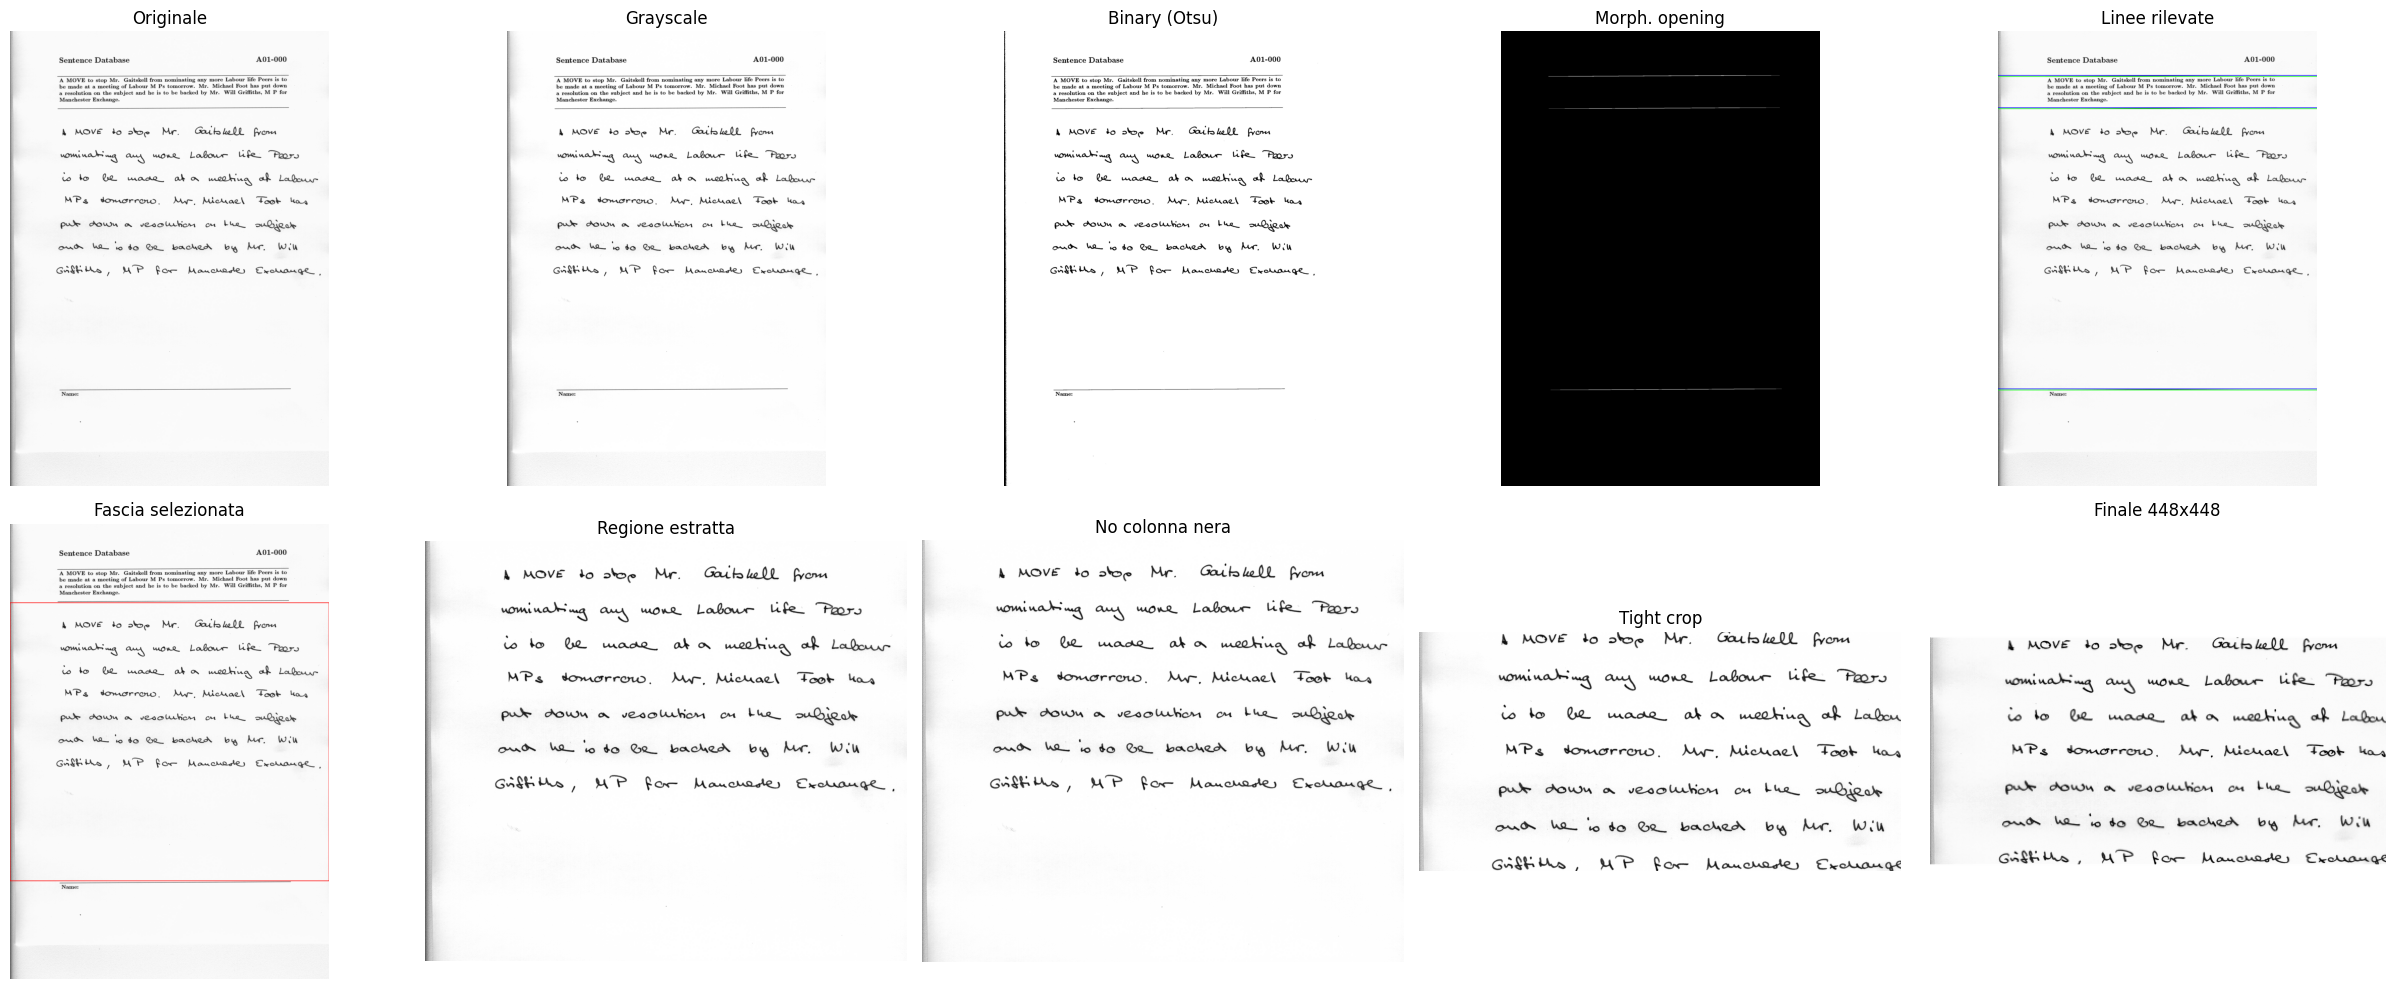

In [15]:
steps = [
    ("01_original.png", "Originale"),
    ("02a_grayscale.png", "Grayscale"),
    ("02b_binary.png", "Binary (Otsu)"),
    ("03b_black_lines.png", "Morph. opening"),
    ("03c_lines_detected.png", "Linee rilevate"),
    ("04_region_selected.png", "Fascia selezionata"),
    ("05a_extracted_gray.png", "Regione estratta"),
    ("06a_gray_cleaned.png", "No colonna nera"),
    ("07b_gray_cropped.png", "Tight crop"),
    ("08_final.png", "Finale 448x448"),
]

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()
for ax, (fname, title) in zip(axes, steps):
    path = os.path.join(OUTPUT_DIR, fname)
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is not None:
        if len(img.shape) == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        else:
            ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "00_summary_grid.png"), dpi=150, bbox_inches="tight")
plt.show()
